# Figure Regeneration — Corrected & Styled
## Cardiovascular Care Deserts in Para, Brazil (2019-2023)

Run this notebook after 03_clustering.ipynb to regenerate all figures
with the project visual identity applied.

**Figures regenerated:**
- 07_elbow_silhouette (fixed annotation position)
- 08_cluster_profiles (styled)
- 09_cluster_map (fixed title spacing, fixed overlapping labels)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import geopandas as gpd
import sys, os
sys.path.insert(0, '..')   
os.makedirs('figures', exist_ok=True)
import style
import importlib
importlib.reload(style)

from style import (apply_style, add_figure_rule, add_source_note,
                   add_separator, title_font, PALETTE, CLUSTER_COLORS, CLUSTER_LABELS)

apply_style()

# Reload data
df         = pd.read_csv('../data/processed/para_cardiovascular_clean.csv',   dtype={'cod_ibge': str})
df_clust   = pd.read_csv('../data/processed/para_cardiovascular_clustered.csv', dtype={'cod_ibge': str})
df_cluster = df_clust[df_clust['cluster'] >= 0].copy()

FEATURES_RAW = ['taxa_mort_100k', 'taxa_proc_100k', 'pib_per_capita', 'crescimento_mort']
REFERENCE_CENTERS = ['BELEM', 'ANANINDEUA']

print("Data loaded")
print(f"  Total municipalities   : {len(df_clust)}")
print(f"  Clustered (non-ref)    : {len(df_cluster)}")
print(f"  Reference centers      : {len(df_clust[df_clust['cluster']==-1])}")

Data loaded
  Total municipalities   : 144
  Clustered (non-ref)    : 142
  Reference centers      : 2


---
## Figure 07 — Elbow & Silhouette (fixed annotation)

Best k = 3  |  Silhouette = 0.3332


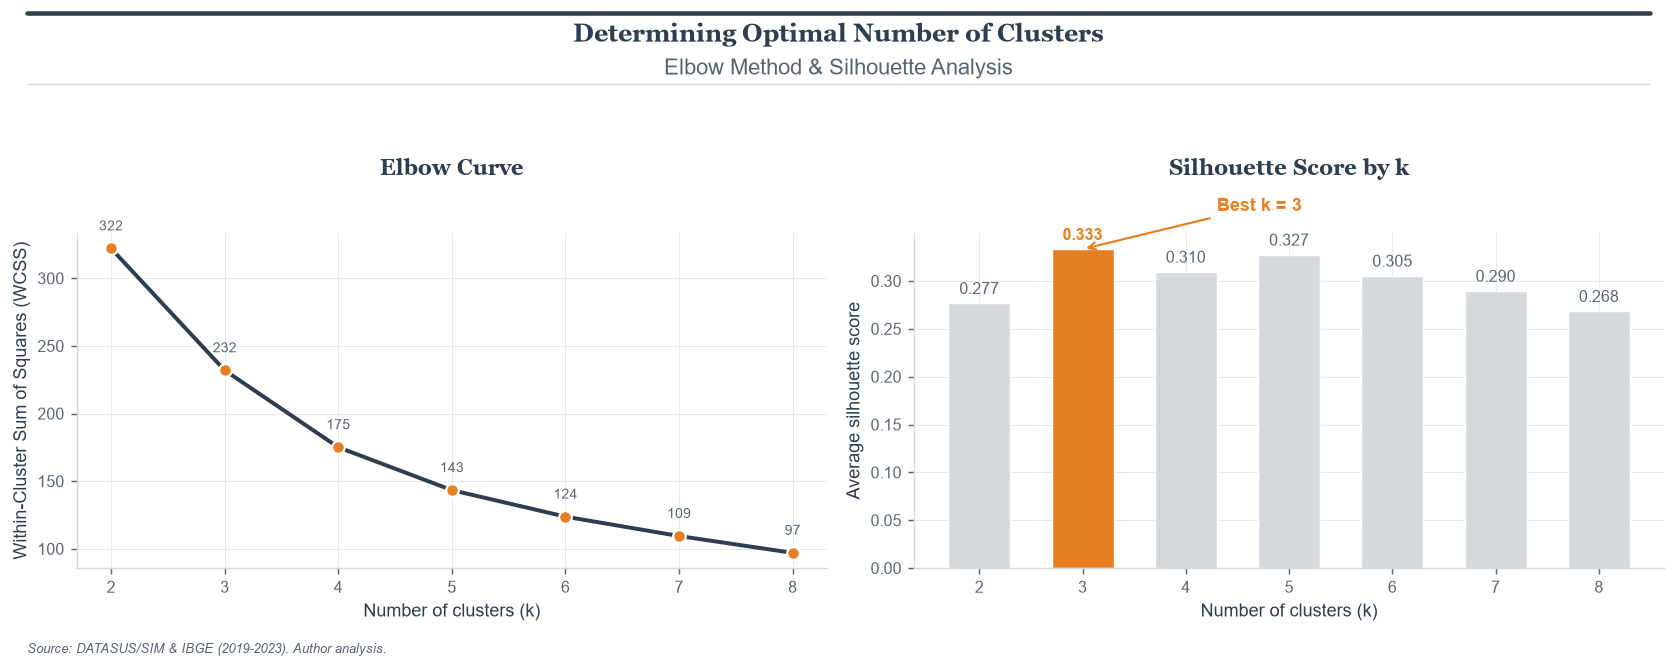

Saved: figures/07_elbow_silhouette.png


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Rebuild scaled features
df_cluster = df_cluster.copy()
df_cluster['log_pib_per_capita'] = np.log(df_cluster['pib_per_capita'])
FEATURES_MODEL = ['taxa_mort_100k', 'taxa_proc_100k', 'log_pib_per_capita', 'crescimento_mort']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[FEATURES_MODEL])

wcss, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k   = list(K_range)[sil_scores.index(max(sil_scores))]
best_sil = max(sil_scores)
print(f"Best k = {best_k}  |  Silhouette = {best_sil:.4f}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Determining Optimal Number of Clusters",
    fontproperties=title_font(14), y=0.98, color=PALETTE["navy"])
fig.text(0.5, 0.90, "Elbow Method & Silhouette Analysis", ha="center", fontsize=12, color=PALETTE["slate"])

add_figure_rule(fig, y=0.995)
add_separator(fig, y=0.885)   

# Left: Elbow
ax = axes[0]
ax.plot(list(K_range), wcss, color=PALETTE["navy"], linewidth=2.2,
        marker='o', markersize=7, markerfacecolor=PALETTE["crimson"],
        markeredgecolor="white", markeredgewidth=1.2)
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Within-Cluster Sum of Squares (WCSS)")
ax.set_title("Elbow Curve", fontproperties=title_font(12), y=1.12)
ax.set_xticks(list(K_range))
for k, w in zip(K_range, wcss):
    ax.annotate(f"{w:.0f}", (k, w),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8, color=PALETTE["slate"])

# Right: Silhouette bars
ax2 = axes[1]
bar_colors = [PALETTE["crimson"] if k == best_k else PALETTE["rule"]
              for k in K_range]
bars = ax2.bar(list(K_range), sil_scores, color=bar_colors,
               edgecolor="white", linewidth=0.8, width=0.6)
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Average silhouette score")
ax2.set_title("Silhouette Score by k", fontproperties=title_font(12), y=1.12)
ax2.set_xticks(list(K_range))

for bar, score, k in zip(bars, sil_scores, K_range):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.006,
             f"{score:.3f}",
             ha="center", va="bottom", fontsize=9,
             color=PALETTE["crimson"] if k == best_k else PALETTE["slate"],
             fontweight="bold" if k == best_k else "normal")

best_bar_height = sil_scores[list(K_range).index(best_k)]
ax2.annotate(
    f"Best k = {best_k}",
    xy=(best_k, best_bar_height),
    xytext=(best_k + 1.3, best_bar_height + 0.040),   
    fontsize=10, color=PALETTE["crimson"], fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=PALETTE["crimson"], lw=1.2)
)

add_source_note(fig)
plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.savefig("figures/07_elbow_silhouette.png")
plt.show()
print("Saved: figures/07_elbow_silhouette.png")

---
## Figure 08 — Cluster Profiles

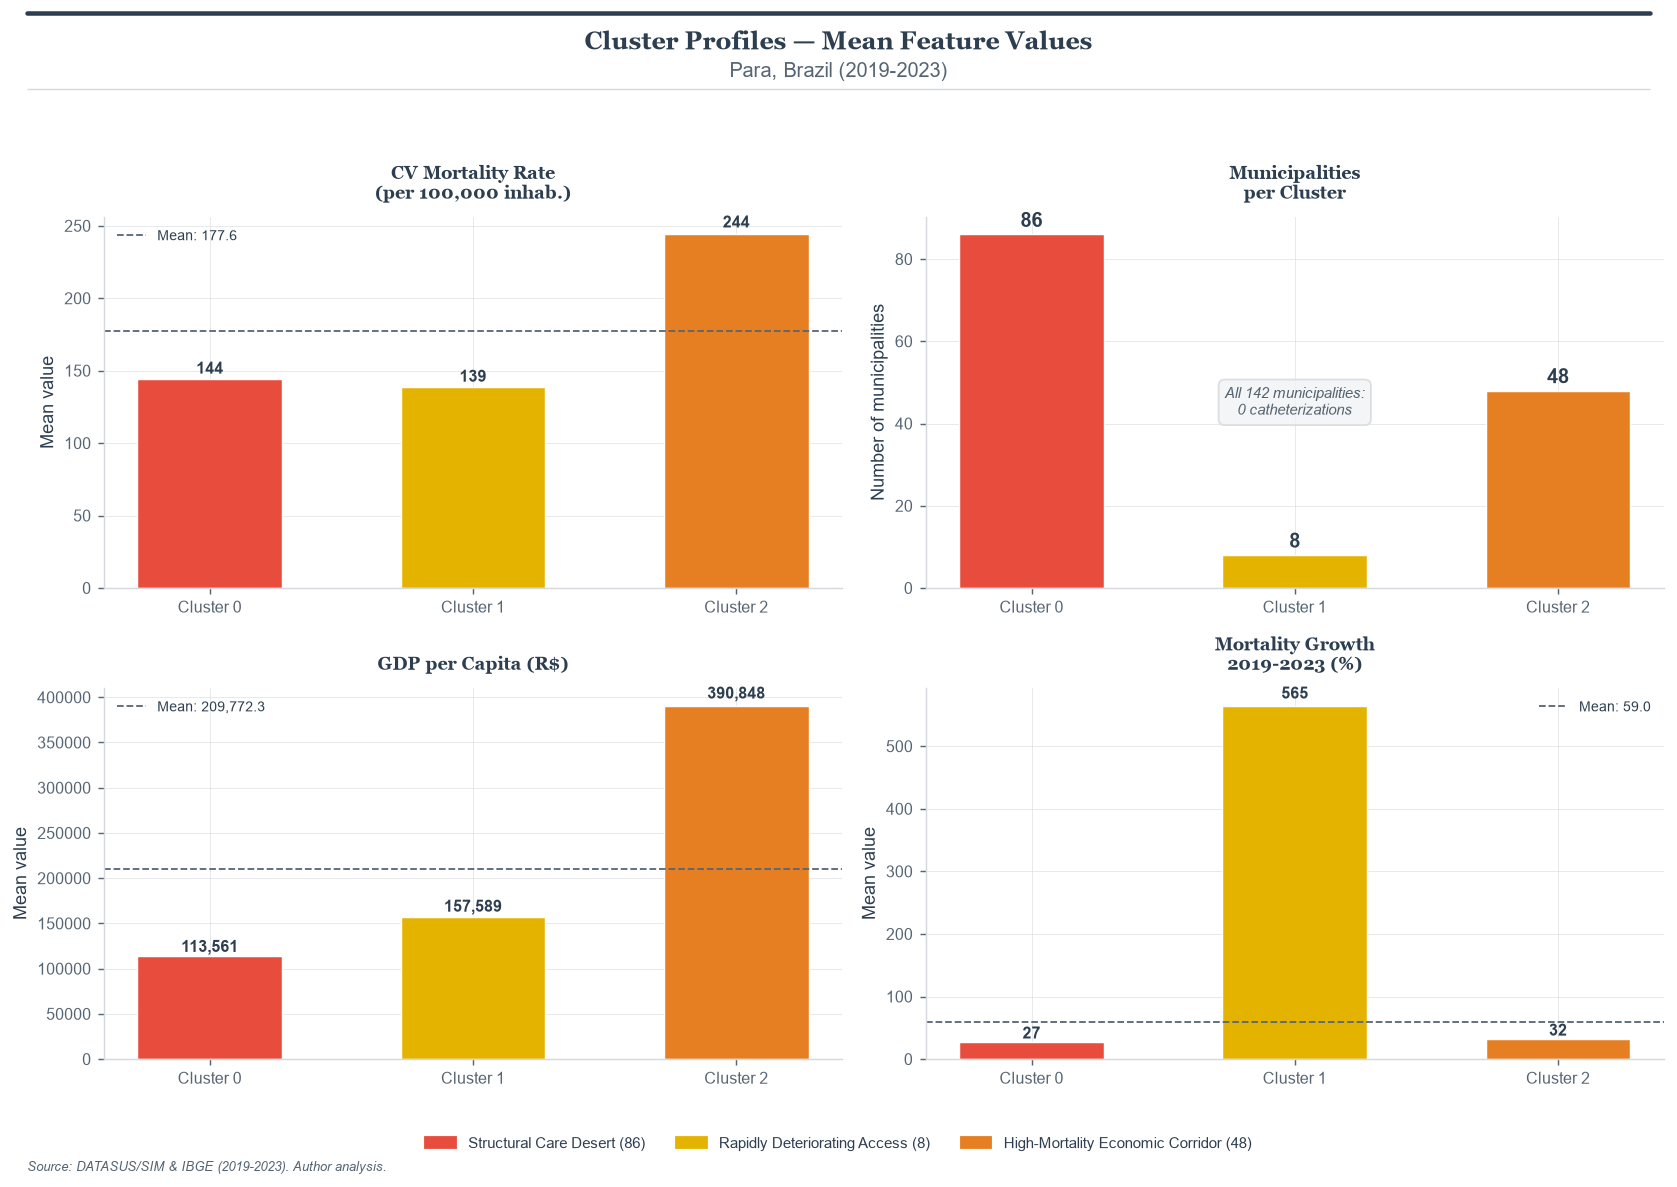

Saved: figures/08_cluster_profiles.png


In [62]:
FEATURE_LABELS = [
    "CV Mortality Rate\n(per 100,000 inhab.)",
    "Municipalities\nper Cluster",          
    "GDP per Capita (R$)",
    "Mortality Growth\n2019-2023 (%)"
]

FEATURE_PLOT = ['taxa_mort_100k', 'count', 'pib_per_capita', 'crescimento_mort']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Cluster Profiles — Mean Feature Values",
             fontproperties=title_font(14), y=0.98, color=PALETTE["navy"])
fig.text(0.5, 0.94, "Para, Brazil (2019-2023)", ha="center", fontsize=11, color=PALETTE["slate"])

add_figure_rule(fig, y=0.995)
add_separator(fig, y=0.93)   

cluster_ids = sorted(df_cluster['cluster'].unique())

for ax, feat, label in zip(axes.flat, FEATURE_PLOT, FEATURE_LABELS):

    if feat == 'count':
        # Panel 2: municipality count per cluster
        counts = df_cluster.groupby('cluster').size()
        bars = ax.bar(
            [f"Cluster {c}" for c in counts.index],
            counts.values,
            color=[CLUSTER_COLORS[c] for c in counts.index],
            edgecolor="white", linewidth=0.8, width=0.55
        )
        ax.set_title(label, fontproperties=title_font(10))
        ax.set_ylabel("Number of municipalities")
        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.8,
                    str(val),
                    ha="center", va="bottom", fontsize=11,
                    fontweight="bold", color=PALETTE["navy"])
        # Note explaining why procedure rate is absent
        ax.text(0.5, 0.5,
                "All 142 municipalities:\n0 catheterizations",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=8.5, color=PALETTE["slate"], style="italic",
                bbox=dict(boxstyle="round,pad=0.4", facecolor=PALETTE["smoke"],
                          edgecolor=PALETTE["rule"], alpha=0.8))
        continue

    means = df_cluster.groupby('cluster')[feat].mean()
    state_mean = df_cluster[feat].mean()

    bars = ax.bar(
        [f"Cluster {c}" for c in means.index],
        means.values,
        color=[CLUSTER_COLORS[c] for c in means.index],
        edgecolor="white", linewidth=0.8, width=0.55
    )
    ax.axhline(state_mean, color=PALETTE["slate"], linestyle="--",
               linewidth=1.0, label=f"Mean: {state_mean:,.1f}")
    ax.set_title(label, fontproperties=title_font(10))
    ax.set_ylabel("Mean value")
    ax.legend(frameon=False, fontsize=8)

    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f"{val:,.0f}",
                ha="center", va="bottom", fontsize=9,
                fontweight="bold", color=PALETTE["navy"])

legend_handles = [
    mpatches.Patch(color=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c])
    for c in cluster_ids
]
fig.legend(handles=legend_handles, loc="lower center",
           ncol=3, frameon=False, fontsize=8.5,
           bbox_to_anchor=(0.5, 0.01))

add_source_note(fig, y=0.005)
plt.tight_layout(rect=[0, 0.06, 1, 0.92])
plt.savefig("figures/08_cluster_profiles.png")
plt.show()
print("Saved: figures/08_cluster_profiles.png")

---
## Figure 09 — Cluster Map (fixed title spacing + label overlap)

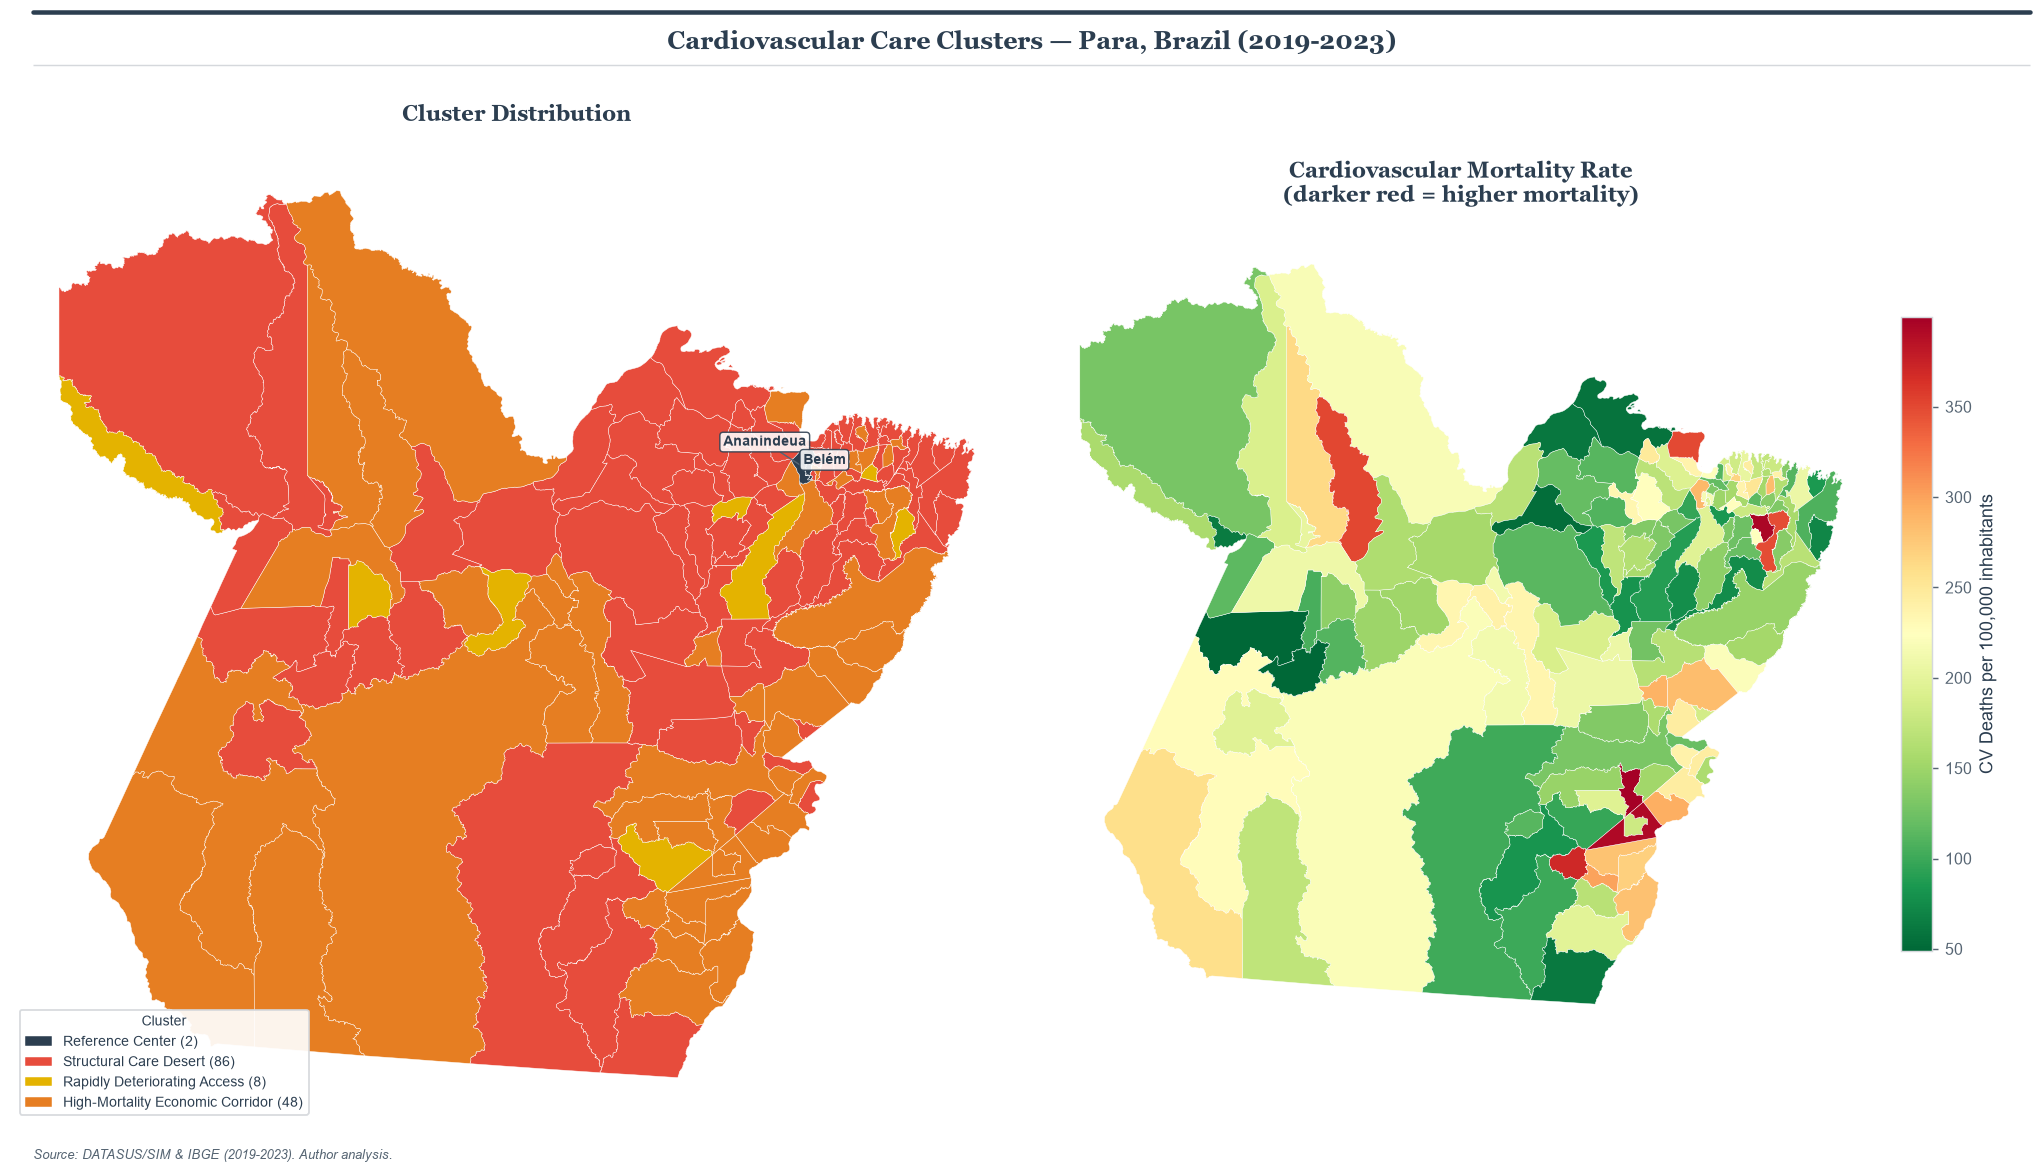

Saved: figures/09_cluster_map.png


In [63]:
PATH_SHAPEFILE = "../data/raw/PA_Municipios_2022.shp"
mapa = gpd.read_file(PATH_SHAPEFILE)
mapa["CD_MUN"] = mapa["CD_MUN"].astype(str).str[:6]

mapa_c = mapa.merge(
    df_clust[["cod_ibge","cluster","cluster_label","taxa_mort_100k","taxa_proc_100k"]],
    left_on="CD_MUN", right_on="cod_ibge", how="left"
)

fig = plt.figure(figsize=(16, 9))

fig.suptitle("Cardiovascular Care Clusters — Para, Brazil (2019-2023)",
             fontproperties=title_font(14), y=0.98, color=PALETTE["navy"])

add_figure_rule(fig, y=0.995)
add_separator(fig, y=0.950)   

ax  = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# ── Left: cluster map ───────────────────────────────────────────────────────
for c in sorted(CLUSTER_COLORS.keys()):
    sub = mapa_c[mapa_c["cluster"] == c]
    if len(sub) == 0:
        continue
    sub.plot(ax=ax, color=CLUSTER_COLORS[c], edgecolor="white",
             linewidth=0.25, label=CLUSTER_LABELS[c])

ref = mapa_c[mapa_c["cluster"] == -1]
ref.plot(ax=ax, color=CLUSTER_COLORS[-1], edgecolor="white", linewidth=0.25)

label_offsets = {
    "BELEM":     ( 0.8,  -0.3),
    "ANANINDEUA":(-1.2,   0.35),
}
for _, row in ref.iterrows():
    name = row["NM_MUN"].upper()
    cx   = row.geometry.centroid.x
    cy   = row.geometry.centroid.y
    dx, dy = label_offsets.get(name, (0, 0))

    ax.annotate(
        row["NM_MUN"].title(),
        xy=(cx, cy),
        xytext=(cx + dx, cy + dy),
        fontsize=7.5, fontweight="bold",
        color=PALETTE["navy"],
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                  edgecolor=PALETTE["navy"], alpha=0.88, linewidth=0.8),
        arrowprops=dict(arrowstyle="-", color=PALETTE["slate"],
                        lw=0.8, shrinkA=0, shrinkB=3)
    )

ax.set_title("Cluster Distribution", fontproperties=title_font(12),
             pad=14, color=PALETTE["navy"])
ax.axis("off")
ax.legend(loc="lower left", fontsize=7.5, frameon=True,
          framealpha=0.92, edgecolor=PALETTE["rule"],
          title="Cluster", title_fontsize=8)

# ── Right: mortality choropleth ─────────────────────────────────────────────
mapa_c.plot(
    column="taxa_mort_100k",
    ax=ax2,
    cmap="RdYlGn_r",
    edgecolor="white",
    linewidth=0.25,
    legend=True,
    missing_kwds={"color": PALETTE["rule"]},
    legend_kwds={
        "label": "CV Deaths per 100,000 inhabitants",
        "orientation": "vertical",
        "shrink": 0.65,
        "pad": 0.02,
    }
)
ax2.set_title("Cardiovascular Mortality Rate\n(darker red = higher mortality)",
              fontproperties=title_font(12), pad=14, color=PALETTE["navy"])
ax2.axis("off")

add_source_note(fig, y=0.015)

plt.tight_layout(rect=[0, 0.03, 1, 0.935])
plt.savefig("figures/09_cluster_map.png")
plt.show()
print("Saved: figures/09_cluster_map.png")

---
## Styling Reference — How to Edit These Settings

All visual identity lives in `style.py` at the project root.
Open it and change the values described below:

| What you want to change | Where in style.py | Parameter |
|---|---|---|
| Title font | `FONT_TITLE` | `'Georgia'` → any installed serif |
| Body font | `FONT_BODY` | `'Arial'` → any installed sans-serif |
| Title size | `apply_style()` | `'figure.titlesize'` |
| Axis label size | `apply_style()` | `'axes.labelsize'` |
| Tick label size | `apply_style()` | `'xtick.labelsize'` |
| Grid on/off | `apply_style()` | `'axes.grid': True/False` |
| Grid color | `apply_style()` | `'grid.color'` |
| Top rule thickness | `add_figure_rule()` | `lw=2.5` |
| Top rule position | `add_figure_rule()` | `y=0.98` |
| Separator position | `add_separator()` | `y=0.93` |
| Source note text | `add_source_note()` | `text=...` |
| Any color | `PALETTE` dict | hex values |

After editing `style.py`, re-run this notebook to apply changes to all figures.